In [ ]:
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm

In [ ]:
ROOT = Path(r"E:\Education\4 course 2 semester\Diploma\panoptic_project\data\LaRS_UNet")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = (512, 512)
BATCH_SIZE = 4
NUM_CLASSES = 3
LR = 1e-4
EPOCHS = 30

In [ ]:
class LaRSUNetDataset(Dataset):
    def __init__(self, root_dir, split="train", image_size=(512, 512)):
        self.root_dir = Path(root_dir)
        self.split = split
        self.img_dir = self.root_dir / split / "images"
        self.lbl_dir = self.root_dir / split / "labels"

        self.image_size = image_size

        self.images = sorted([p for p in self.img_dir.iterdir() if p.is_file()])

        self.labels = [self.lbl_dir / (p.stem + ".png") for p in self.images]

        assert all(l.exists() for l in self.labels), "Some labels are missing"

        self.img_transform = transforms.Compose([
            transforms.Resize(self.image_size, interpolation=Image.BILINEAR),
            transforms.ToTensor(),  # [0,1]
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

        self.lbl_resize = transforms.Resize(self.image_size,
                                            interpolation=Image.NEAREST)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        lbl_path = self.labels[idx]

        img = Image.open(img_path).convert("RGB")
        lbl = Image.open(lbl_path)

        img = self.img_transform(img)
        lbl = self.lbl_resize(lbl)
        lbl = torch.from_numpy(np.array(lbl, dtype=np.int64))

        return img, lbl

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.down1 = DoubleConv(3, 32)
        self.down2 = DoubleConv(32, 64)
        self.down3 = DoubleConv(64, 128)
        self.down4 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)

        self.up4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv4 = DoubleConv(256 + 256, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv3 = DoubleConv(128 + 128, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(64 + 64, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(32 + 32, 32)

        self.out_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool(c1)

        c2 = self.down2(p1)
        p2 = self.pool(c2)

        c3 = self.down3(p2)
        p3 = self.pool(c3)

        c4 = self.down4(p3)
        p4 = self.pool(c4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        logits = self.out_conv(c8)
        return logits

In [7]:
device = DEVICE

train_ds = LaRSUNetDataset(ROOT, split="train", image_size=IMG_SIZE)
val_ds   = LaRSUNetDataset(ROOT, split="val",   image_size=IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=0, pin_memory=True, drop_last=True)

In [ ]:
model = UNet(n_classes=3).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=255)  
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_epoch():
    model.train()
    total_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc="Train"):
        imgs = imgs.to(device)
        labels = labels.to(device)  

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(train_ds)

@torch.no_grad()
def eval_epoch():
    model.eval()
    total_loss = 0.0
    for imgs, labels in tqdm(val_loader, desc="Val"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)

    return total_loss / len(val_ds)

num_epochs = 30
best_val = float("inf")

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    val_loss   = eval_epoch()
    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), r"E:\Education\4 course 2 semester\Diploma\panoptic_project\runs\semantic_segmentation\UNet\unet_lars_best.pth")
        print("Saved best model")

Val: 100%|██████████| 49/49 [00:09<00:00,  4.91it/s]


Epoch 1: train_loss=0.4214, val_loss=0.4173
Saved best model


Val: 100%|██████████| 49/49 [00:09<00:00,  4.90it/s]


Epoch 2: train_loss=0.2359, val_loss=0.2902
Saved best model


Val: 100%|██████████| 49/49 [00:09<00:00,  4.92it/s]


...

Epoch 28: train_loss=0.0444, val_loss=0.1640


Val: 100%|██████████| 49/49 [00:10<00:00,  4.75it/s]


Epoch 29: train_loss=0.0383, val_loss=0.1786


Val: 100%|██████████| 49/49 [00:09<00:00,  4.92it/s]

Epoch 30: train_loss=0.0378, val_loss=0.1665


In [25]:
model = UNet(n_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(r"E:\Education\4 course 2 semester\Diploma\panoptic_project\runs\semantic_segmentation\UNet\unet_lars_best.pth"))
model = model.cuda()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.08956].


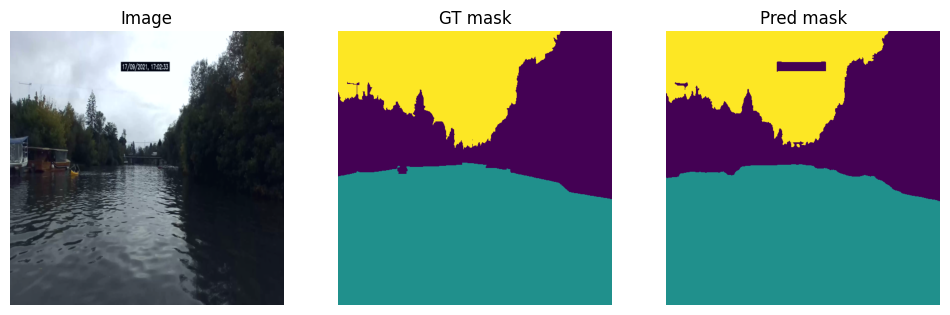

In [ ]:
model.eval()
img, lbl = val_ds[0]
with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    pred = torch.argmax(logits, dim=1)[0].cpu()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img.permute(1, 2, 0).cpu().numpy() * 0.229 + 0.485)  
axes[0].set_title("Image")
axes[1].imshow(lbl.cpu(), vmin=0, vmax=2)
axes[1].set_title("GT mask")
axes[2].imshow(pred.cpu(), vmin=0, vmax=2)
axes[2].set_title("Pred mask")
for ax in axes: ax.axis("off")
plt.show()

In [ ]:
import numpy as np
import torch
from tqdm import tqdm

IGNORE_INDEX = 255
NUM_CLASSES = 3 

def compute_iou_per_class(model, dataloader, device, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    model.eval()

    intersection = np.zeros(num_classes, dtype=np.float64)
    union = np.zeros(num_classes, dtype=np.float64)

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="IoU"):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            if ignore_index is not None:
                valid = (masks != ignore_index)
                preds = preds[valid]
                masks = masks[valid]

            for cls in range(num_classes):
                pred_cls = (preds == cls)
                mask_cls = (masks == cls)

                inter = (pred_cls & mask_cls).sum().item()
                u = (pred_cls | mask_cls).sum().item()

                intersection[cls] += inter
                union[cls] += u

    iou = intersection / (union + 1e-6)
    return iou

In [32]:
def compute_pixel_accuracy(model, dataloader, device, ignore_index=IGNORE_INDEX):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="PixelAcc"):
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            if ignore_index is not None:
                valid = (masks != ignore_index)
                preds = preds[valid]
                masks = masks[valid]

            correct += (preds == masks).sum().item()
            total += masks.numel() if ignore_index is None else valid.sum().item()

    return correct / total

In [33]:
class_names = ["obstacle", "water", "sky"]

In [34]:
ious_unet = compute_iou_per_class(model, val_loader, device)

for i, name in enumerate(class_names):
    print(f"{name}: IoU = {ious_unet[i]:.4f}")

miou_unet = np.mean(ious_unet)
print("\nUNet mIoU:", miou_unet)

pixel_acc_unet = compute_pixel_accuracy(model, val_loader, device)
print("UNet Pixel Accuracy:", pixel_acc_unet)

IoU: 100%|██████████| 49/49 [00:09<00:00,  5.12it/s]


obstacle: IoU = 0.8659
water: IoU = 0.9267
sky: IoU = 0.9339

UNet mIoU: 0.9088500413553247


PixelAcc: 100%|██████████| 49/49 [00:09<00:00,  5.21it/s]

UNet Pixel Accuracy: 0.9538490109651031
